<a href="https://colab.research.google.com/github/MeanrithYurin/4Y/blob/main/face_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install face_recognition opencv-python

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving yurin.JPG to yurin (1).JPG


In [ ]:
import face_recognition
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Change this name if your file name is different
known_image = face_recognition.load_image_file("yurin.JPG")

known_encodings = face_recognition.face_encodings(known_image)

if len(known_encodings) == 0:
    print("No face found in your uploaded image. Please upload a clearer photo.")
else:
    known_face_encoding = known_encodings[0]
    known_face_names = ["Yurin"]
    print("Your face loaded successfully.")

Your face loaded successfully.


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='webcam_photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture Photo';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';

            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(div);
            div.appendChild(video);

            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getVideoTracks()[0].stop();
            div.remove();

            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')

    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename
take_photo()

<IPython.core.display.Javascript object>

'webcam_photo.jpg'

Faces found: 3


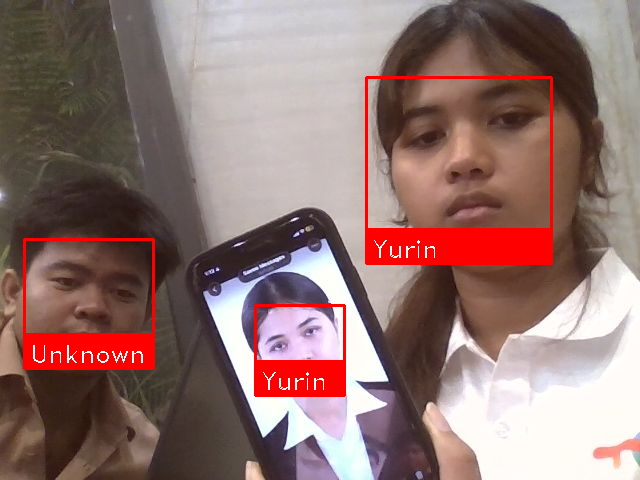

In [ ]:
image = face_recognition.load_image_file("webcam_photo.jpg")

frame = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

face_locations = face_recognition.face_locations(image)
face_encodings = face_recognition.face_encodings(image, face_locations)

print("Faces found:", len(face_locations))

for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):
    matches = face_recognition.compare_faces([known_face_encoding], face_encoding)
    name = "Unknown"

    face_distances = face_recognition.face_distance([known_face_encoding], face_encoding)
    best_match_index = np.argmin(face_distances)

    if matches[best_match_index]:
        name = known_face_names[best_match_index]

    cv2.rectangle(frame, (left, top), (right, bottom), (0, 0, 255), 2)

    cv2.rectangle(frame, (left, bottom - 35), (right, bottom), (0, 0, 255), cv2.FILLED)

    cv2.putText(
        frame,
        name,
        (left + 6, bottom - 6),
        cv2.FONT_HERSHEY_DUPLEX,
        0.8,
        (255, 255, 255),
        1
    )

cv2_imshow(frame)